Un approach seria no fer servir CNNs sino fer servir ML clàssic
(SVM x exemple).

Hi ha una mètrica que indica la intensitat de dopamina en el nucli. En un
pacient PD, no tot el nucli s ilumina, hi haurà menys intensitat q un HC. 4-5 és
alt. Es pot treure de manera manual.

Al PPMI està ja tret:

- La mètrica està a les columnes EJ, EK, EO i EP al
    excel `/home/data/PPMI/documents/PPMI_Curated_Data_Cut_Public_20240729.xlsx`

Ara l'approach estaria en comparar les prediccions que fa un model a partir de
només aquests quatre paràmetres AMB ELS MATEIXOS PACIENTS test/train que amb els
models CNN que ja he fet.

És a dir, si la meva CNN prediu un pacient com a HC a partir de la imatge i si
la SVM entrenada amb només aquest indicador prediu que serà HC o no.

Classificar segons aquest indicador enlloc de ferho automàtic


Al PPMI està amb putamen i caudate. agafar igual test/train. Entrenar un LR amb
les 4 característiques, entrenar amb scikit i comparar resultats PD o HC amb
SVM/ML genèric. Això fer amb el rawdata i amb el derivatives.

Per aquesta part podem agafar la llibreria `scikitlearn`.


- **CV**: Cross-Validation. A model evaluation technique that splits the data into k folds, training on k-1 and testing on the remaining one, rotating until every fold has been the test set once. Here k=5.
- **SVM**: Support Vector Machine. A classifier that finds the hyperplane maximally separating two classes in feature space.
- **RBF**: Radial Basis Function. The kernel used by the non-linear SVM; maps data into a higher-dimensional space so non-linearly separable classes can be split. Controlled by the γ (gamma) parameter.
- **SVM Lin**: SVM with a linear kernel. No transformation, just a straight hyperplane. Faster and more interpretable, but assumes the classes are linearly separable.
- **RF**: Random Forest. An ensemble of decision trees, each trained on a random subset of samples and features, with the final prediction taken by majority vote.
- **GB**: Gradient Boosting. Another tree ensemble, but trees are built sequentially, each correcting the errors of the previous one. Slower to train than RF but often more accurate.
- **LR**: Logistic Regression. A linear probabilistic classifier; despite the name it is a classification model, outputting the probability of belonging to each class.
- **AUC / ROC-AUC**: Area Under the Receiver Operating Characteristic Curve. The ROC curve plots true positive rate against false positive rate at every classification threshold; the AUC summarises it as a single number (0.5 = random, 1.0 = perfect).
- **Bal. Acc. / Balanced Accuracy**: Average of sensitivity and specificity. Unlike raw accuracy, it is not inflated by class imbalance, making it the more honest metric here given the 10:1 PD/HC ratio.
- **F1**: Harmonic mean of precision and recall. Useful when false negatives and false positives carry different costs, which is the case in clinical classification.
- **SBR**: Striatal Binding Ratio. The DaTscan-derived metric quantifying dopamine transporter density in a striatal region, computed relative to a background reference region. Lower values indicate dopaminergic deficit.
- **AI**: Asymmetry Index. Engineered feature computed as |L − R| / mean(L, R) for a pair of symmetric regions. PD characteristically shows higher asymmetry than healthy controls.
- **HC**: Healthy Control. PPMI cohort 2; participants with no neurological diagnosis enrolled as a reference population.
- **PD**: Parkinson's Disease. PPMI cohort 1; participants with a confirmed clinical diagnosis of idiopathic Parkinson's disease.
- **SWEDD**: Scans Without Evidence of Dopaminergic Deficit. PPMI cohort 3; clinically diagnosed as PD but with a normal DaTscan, suggesting a different underlying aetiology.
- **PPMI**: Parkinson's Progression Markers Initiative. A large longitudinal multicentre study collecting imaging, biomarker, and clinical data to identify PD progression markers.

In [2]:
# excel path n variables
DATA_PATH = "/home/data/PPMI/documents/PPMI_Curated_Data_Cut_Public_20240729.xlsx"
FEATURE_COLS = ['DATSCAN_CAUDATE_L', 'DATSCAN_CAUDATE_R', 'DATSCAN_PUTAMEN_L', 'DATSCAN_PUTAMEN_R']

LABEL_COL = "COHORT"
 
LABEL_MAP = {1: 1, 2: 0}   # 1 = PD, 0 = HC
RANDOM_STATE = 42
CV_FOLDS = 5

# get data from excel into pd
import pandas as pd
df = pd.read_excel(DATA_PATH, header=0)

cols_needed = FEATURE_COLS + [ LABEL_COL ]
df = df[cols_needed].copy()


df[LABEL_COL] = df[LABEL_COL].map(LABEL_MAP)


# porsiaca
df.dropna(subset=[LABEL_COL], inplace=True)
df.dropna(subset=FEATURE_COLS, inplace=True)


df[LABEL_COL] = df[LABEL_COL].astype(int)

 
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"After cleaning: {df.shape[0]} samples")
print(df[LABEL_COL].value_counts())

Loaded 3362 rows, 5 columns.
After cleaning: 3362 samples
COHORT
1    3066
0     296
Name: count, dtype: int64


## Separate dataset into X (features) - Y (label)

In [3]:
X = df[FEATURE_COLS].values
y = df["COHORT"].values

print(f"x: {X.shape}")
print(f"y: {y.shape}")

# print(X)
# print(y)

print(f"PD: {(y==1).sum()},  HC: {(y==0).sum()}")

x: (3362, 4)
y: (3362,)
PD: 3066,  HC: 296


Now the data is clean. There is a total of 3362 patients and 4 features.
We could add some extra features like assymetry, but first lets just run as-is.

## Fixing the imbalance

In [4]:
# This tells sklearn to penalise misclassifying the minority class (HC)
# proportionally to how under-represented it is
 
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight("balanced", y)

Not all classifiers suport the `sample_weight` parameter though.

# Creating the classifiers

In order to create the different classifiers I'll keep them in a dictionary.

In [5]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

In [6]:

classifiers = {
    "SVM (RBF)":           SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "SVM (Linear)":        SVC(kernel="linear", C=1.0, probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
}

# Evaluate them

Using 5-fold stratified cross-validation.

In [7]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "balanced_accuracy", "roc_auc", "f1", "precision", "recall"]
 
cv_results = {}
print("5-Fold Stratified CV, raw features only")
 
for name, clf in classifiers.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = scores
    print(f"\n{name}")
    print(f"  Balanced Accuracy : {scores['test_balanced_accuracy'].mean():.3f} ± {scores['test_balanced_accuracy'].std():.3f}")
    print(f"  ROC-AUC           : {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")
    print(f"  F1                : {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")
    print(f"  Recall (Sens.)    : {scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}")
    print(f"  Precision         : {scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}")

5-Fold Stratified CV, raw features only

SVM (RBF)
  Balanced Accuracy : 0.974 ± 0.007
  ROC-AUC           : 0.988 ± 0.005
  F1                : 0.983 ± 0.002
  Recall (Sens.)    : 0.968 ± 0.004
  Precision         : 0.998 ± 0.001

SVM (Linear)
  Balanced Accuracy : 0.967 ± 0.009
  ROC-AUC           : 0.991 ± 0.003
  F1                : 0.981 ± 0.003
  Recall (Sens.)    : 0.965 ± 0.004
  Precision         : 0.997 ± 0.002

Random Forest
  Balanced Accuracy : 0.946 ± 0.013
  ROC-AUC           : 0.988 ± 0.006
  F1                : 0.989 ± 0.002
  Recall (Sens.)    : 0.986 ± 0.006
  Precision         : 0.991 ± 0.003

Gradient Boosting
  Balanced Accuracy : 0.939 ± 0.016
  ROC-AUC           : 0.986 ± 0.007
  F1                : 0.988 ± 0.002
  Recall (Sens.)    : 0.986 ± 0.005
  Precision         : 0.990 ± 0.003

Logistic Regression
  Balanced Accuracy : 0.966 ± 0.012
  ROC-AUC           : 0.991 ± 0.003
  F1                : 0.982 ± 0.003
  Recall (Sens.)    : 0.968 ± 0.005
  Precision     

Now compare the results using a boxplot.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

/tmp/ipykernel_383277/2587079579.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=short_names)
/tmp/ipykernel_383277/2587079579.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=short_names)
/tmp/ipykernel_383277/2587079579.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=short_names)


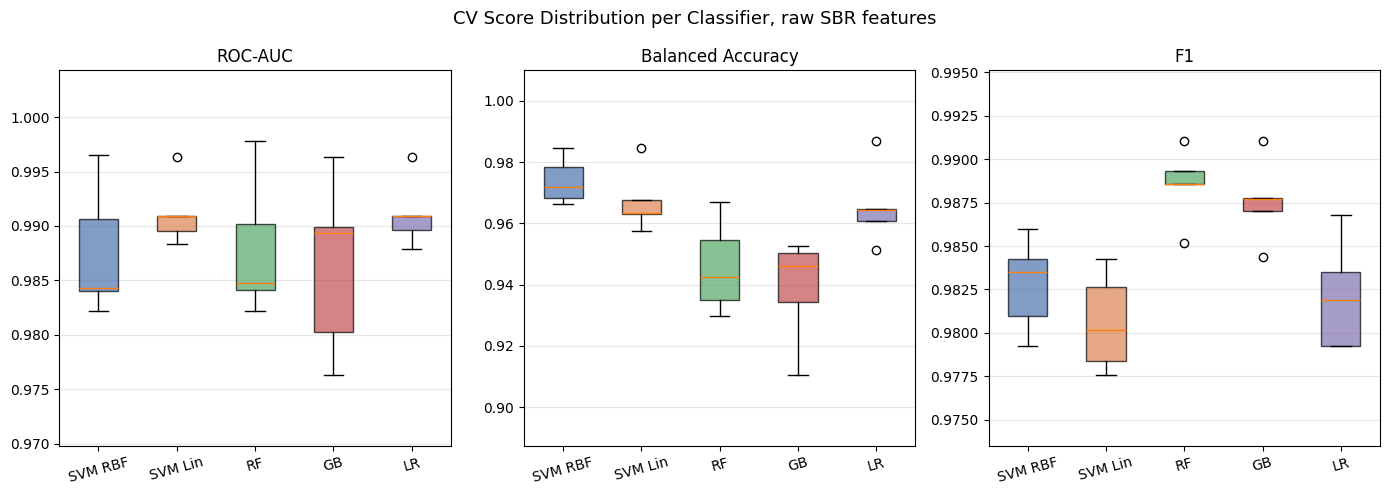

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = {"ROC-AUC": "test_roc_auc", "Balanced Accuracy": "test_balanced_accuracy", "F1": "test_f1"}
names = list(cv_results.keys())
short_names = ["SVM RBF", "SVM Lin", "RF", "GB", "LR"]

for ax, (metric_label, key) in zip(axes, metrics.items()):
    data = [cv_results[n][key] for n in names]
    bp = ax.boxplot(data, patch_artist=True, labels=short_names)
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    min_val = min(d.min() for d in data)
    max_val = max(d.max() for d in data)
    margin = (max_val - min_val) * 0.3
    ax.set_ylim(min_val - margin, max_val + margin)
    #ax.set_ylim(0.75, 1.05)

    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("CV Score Distribution per Classifier, raw SBR features", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)  # force rescan
fm.fontManager.addfont("/home/akarel/.local/share/fonts/LinLibertine_R.ttf")  # explicit add
[f.name for f in fm.fontManager.ttflist if "Libertine" in f.name or "Libertinus" in f.name]

['Linux Libertine Capitals',
 'Linux Libertine',
 'Linux Libertine Capitals',
 'Linux Libertine',
 'Linux Libertine',
 'Linux Libertine Capitals',
 'Linux Libertine Slanted',
 'Linux Libertine Display Capitals',
 'Linux Libertine Initials',
 'Linux Libertine',
 'Linux Libertine',
 'Linux Libertine',
 'Linux Libertine Slanted',
 'Linux Libertine Display',
 'Linux Libertine Capitals',
 'Linux Libertine Slanted',
 'Linux Libertine']

/tmp/ipykernel_383277/1379407832.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=short_names)
/tmp/ipykernel_383277/1379407832.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=short_names)
/tmp/ipykernel_383277/1379407832.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=short_names)


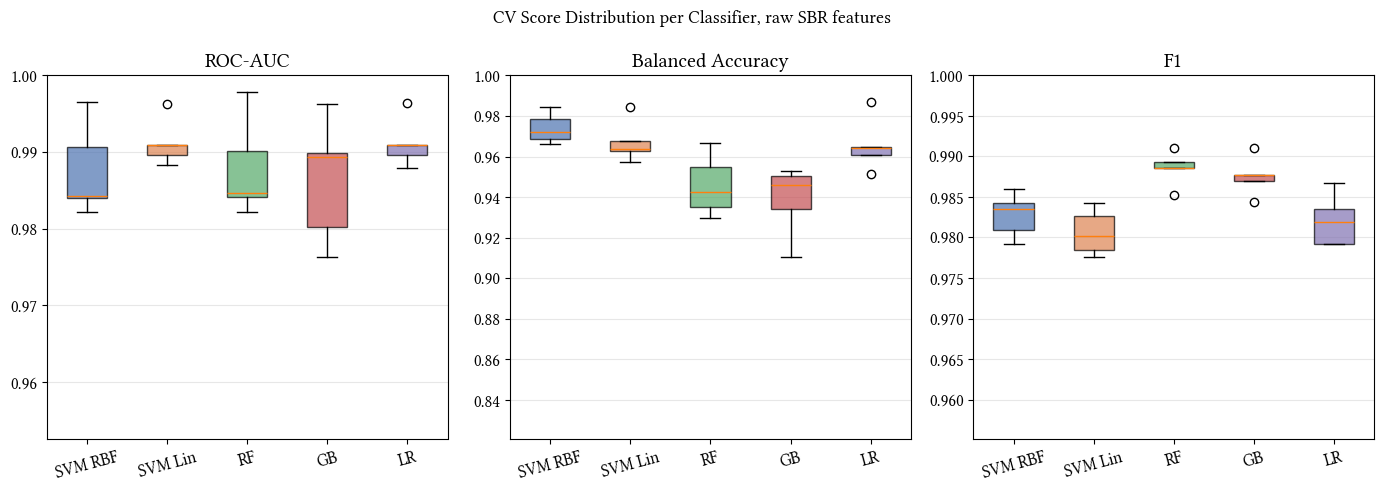

In [11]:
import matplotlib
matplotlib.rcParams["font.family"] = "Linux Libertine"
matplotlib.rcParams["font.size"] = 12

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = {"ROC-AUC": "test_roc_auc", "Balanced Accuracy": "test_balanced_accuracy", "F1": "test_f1"}
names = list(cv_results.keys())
short_names = ["SVM RBF", "SVM Lin", "RF", "GB", "LR"]

for ax, (metric_label, key) in zip(axes, metrics.items()):
    data = [cv_results[n][key] for n in names]
    bp = ax.boxplot(data, patch_artist=True, labels=short_names)
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    min_val = min(d.min() for d in data)
    max_val = max(d.max() for d in data)
    margin = (1.0 - min_val)
    ax.set_ylim(min_val - margin, 1.0)
    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("CV Score Distribution per Classifier, raw SBR features", fontsize=13)
plt.tight_layout()
plt.savefig("classifier_boxplots.svg", format="svg", bbox_inches="tight")
plt.show()

## About this graph

This graph shows performance using only the DaTscan derived data (the 4 metrics del excel que n'Adrià m va dir), this serves as a baseline before adding new data.

These models, though, have been trained using the `weighted` balancing method that is not really all that good.


SVM (RBF): hold-out report
              precision    recall  f1-score   support

          HC       0.69      0.95      0.80        59
          PD       0.99      0.96      0.98       614

    accuracy                           0.96       673
   macro avg       0.84      0.95      0.89       673
weighted avg       0.97      0.96      0.96       673



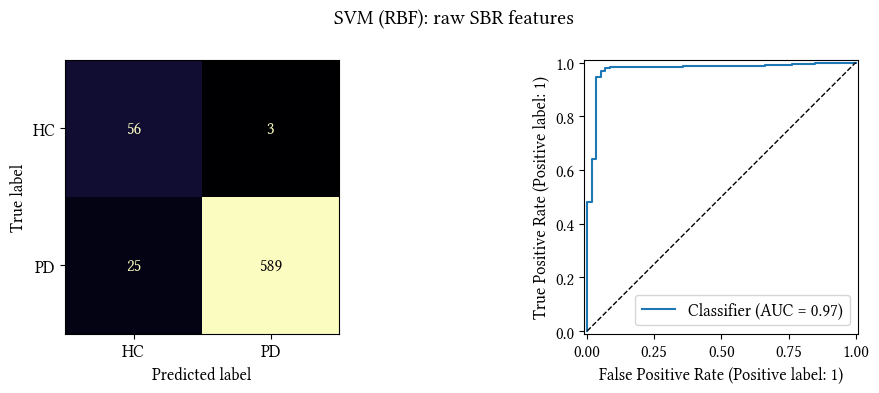

In [12]:
from sklearn.model_selection import train_test_split
 
# This should be changed for the model I want to see
best_name = "SVM (RBF)"
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
 
best_pipe = Pipeline([("scaler", StandardScaler()), ("clf", classifiers[best_name])])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]
 
print(f"\n{best_name}: hold-out report")
print(classification_report(y_test, y_pred, target_names=["HC", "PD"]))
 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["HC", "PD"], ax=axes[0], colorbar=False, cmap="magma")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].plot([0,1],[0,1],"k--", lw=1)
fig.suptitle(f"{best_name}: raw SBR features")
plt.tight_layout()
plt.show()

# Adding artificial features

Now retrain with the engineered features to see if the performance increases.

These are:
- `AI_Caudate`: (Assymetry Index Caudate).
- `AI_Putamen`: (Assymetry Index Putamen).
- `Mean_SBR`: overall dopaminergic integrity.
- `Putamen_Caudate_Ratio`: Putamen / Caudate ratio. The putamen is typically more affected than caudate in early PD.

In [13]:
# Engineered features
eps = 1e-6 # avoid 0 div
df["AI_Caudate"]           = (df["DATSCAN_CAUDATE_L"] - df["DATSCAN_CAUDATE_R"]).abs() / ((df["DATSCAN_CAUDATE_L"] + df["DATSCAN_CAUDATE_R"]) / 2 + eps)
df["AI_Putamen"]           = (df["DATSCAN_PUTAMEN_L"] - df["DATSCAN_PUTAMEN_R"]).abs() / ((df["DATSCAN_PUTAMEN_L"] + df["DATSCAN_PUTAMEN_R"]) / 2 + eps)
df["Mean_SBR"]             = df[["DATSCAN_PUTAMEN_L", "DATSCAN_PUTAMEN_R", "DATSCAN_CAUDATE_L", "DATSCAN_CAUDATE_R"]].mean(axis=1)
df["Putamen_Caudate_Ratio"] = ((df["DATSCAN_PUTAMEN_L"] + df["DATSCAN_PUTAMEN_R"]) / 2) / ((df["DATSCAN_CAUDATE_L"] + df["DATSCAN_CAUDATE_R"]) / 2 + eps)


FEATURE_COLS_ENG = FEATURE_COLS + [ "AI_Caudate", "AI_Putamen", "Mean_SBR", "Putamen_Caudate_Ratio"]

X_eng = df[FEATURE_COLS_ENG].values
y_eng = df["COHORT"].values

In [14]:
# CV on engineered features
cv_results_eng = {}
print("5-Fold CV:  raw + engineered features")

for name, clf in classifiers.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    scores = cross_validate(pipe, X_eng, y_eng, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results_eng[name] = scores
    print(f"\n{name}")
    print(f"  Balanced Accuracy : {scores['test_balanced_accuracy'].mean():.3f} ± {scores['test_balanced_accuracy'].std():.3f}")
    print(f"  ROC-AUC           : {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")
    print(f"  F1                : {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")
    print(f"  Recall (Sens.)    : {scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}")
    print(f"  Precision         : {scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}")


5-Fold CV:  raw + engineered features

SVM (RBF)
  Balanced Accuracy : 0.975 ± 0.009
  ROC-AUC           : 0.990 ± 0.006
  F1                : 0.984 ± 0.003
  Recall (Sens.)    : 0.970 ± 0.005
  Precision         : 0.998 ± 0.002

SVM (Linear)
  Balanced Accuracy : 0.971 ± 0.013
  ROC-AUC           : 0.994 ± 0.002
  F1                : 0.983 ± 0.004
  Recall (Sens.)    : 0.970 ± 0.006
  Precision         : 0.997 ± 0.002

Random Forest
  Balanced Accuracy : 0.943 ± 0.016
  ROC-AUC           : 0.990 ± 0.006
  F1                : 0.989 ± 0.003
  Recall (Sens.)    : 0.987 ± 0.006
  Precision         : 0.990 ± 0.003

Gradient Boosting
  Balanced Accuracy : 0.939 ± 0.013
  ROC-AUC           : 0.990 ± 0.006
  F1                : 0.988 ± 0.001
  Recall (Sens.)    : 0.987 ± 0.005
  Precision         : 0.990 ± 0.003

Logistic Regression
  Balanced Accuracy : 0.971 ± 0.011
  ROC-AUC           : 0.994 ± 0.002
  F1                : 0.984 ± 0.004
  Recall (Sens.)    : 0.972 ± 0.007
  Precision       

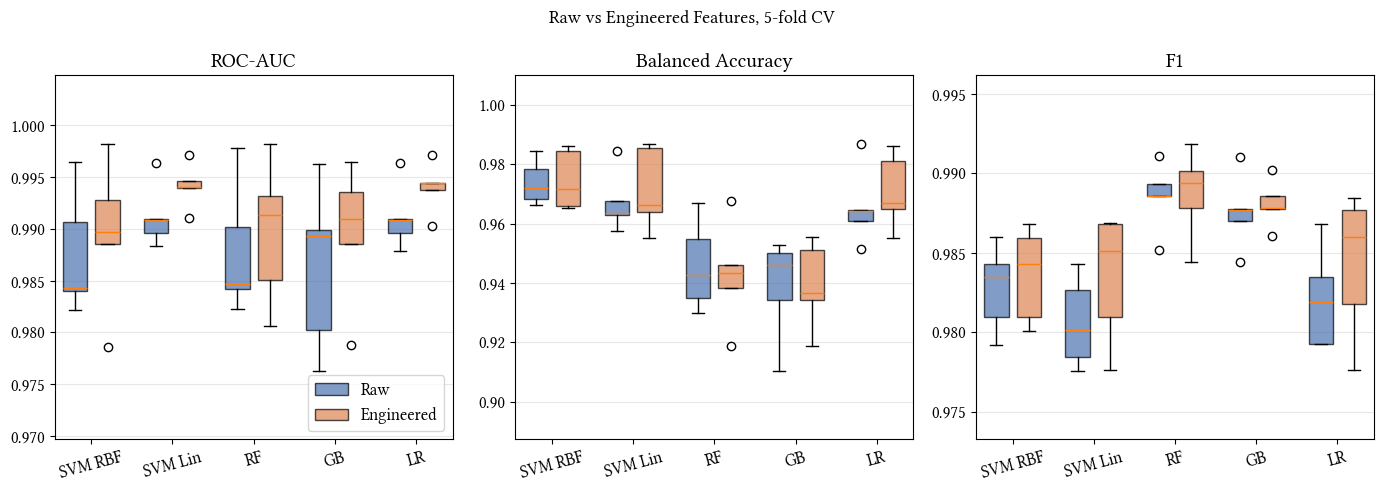

In [15]:
# Side-by-side boxplot comparison: raw vs engineered

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = {"ROC-AUC": "test_roc_auc", "Balanced Accuracy": "test_balanced_accuracy", "F1": "test_f1"}
short_names = ["SVM RBF", "SVM Lin", "RF", "GB", "LR"]

for ax, (metric_label, key) in zip(axes, metrics.items()):
    data_raw = [cv_results[n][key]     for n in names]
    data_eng = [cv_results_eng[n][key] for n in names]

    positions_raw = np.arange(len(names)) * 2
    positions_eng = positions_raw + 0.8

    bp1 = ax.boxplot(data_raw, positions=positions_raw, widths=0.6, patch_artist=True)
    bp2 = ax.boxplot(data_eng, positions=positions_eng, widths=0.6, patch_artist=True)

    for patch in bp1["boxes"]: patch.set(facecolor="#4C72B0", alpha=0.7)
    for patch in bp2["boxes"]: patch.set(facecolor="#DD8452", alpha=0.7)

    all_vals = [v for d in data_raw + data_eng for v in d]
    margin = (max(all_vals) - min(all_vals)) * 0.3
    ax.set_ylim(min(all_vals) - margin, max(all_vals) + margin)
    ax.set_xticks(positions_raw + 0.4)
    ax.set_xticklabels(short_names, rotation=15)
    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)

axes[0].legend([bp1["boxes"][0], bp2["boxes"][0]], ["Raw", "Engineered"], loc="lower right")
fig.suptitle("Raw vs Engineered Features, 5-fold CV", fontsize=13)
plt.tight_layout()
plt.savefig("boxplot_raw_vs_eng.svg", format="svg", bbox_inches="tight")
plt.show()

## About this one

This plot evaluates different models' performance using both raw (the 4 params, putamenL + R + caudateL + R) vs adding engineered or artificial features.

These artificial measures are:
- `AI_Caudate`: (Assymetry Index Caudate).
- `AI_Putamen`: (Assymetry Index Putamen).
- `Mean_SBR`: overall dopaminergic integrity.
- `Putamen_Caudate_Ratio`: Putamen / Caudate ratio. The putamen is typically more affected than caudate in early PD.

No extra data, just deriving from what we have and the performance on average has increased.


SVM (RBF) — engineered features, hold-out report
              precision    recall  f1-score   support

          HC       0.73      0.95      0.82        59
          PD       0.99      0.97      0.98       614

    accuracy                           0.96       673
   macro avg       0.86      0.96      0.90       673
weighted avg       0.97      0.96      0.97       673



/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


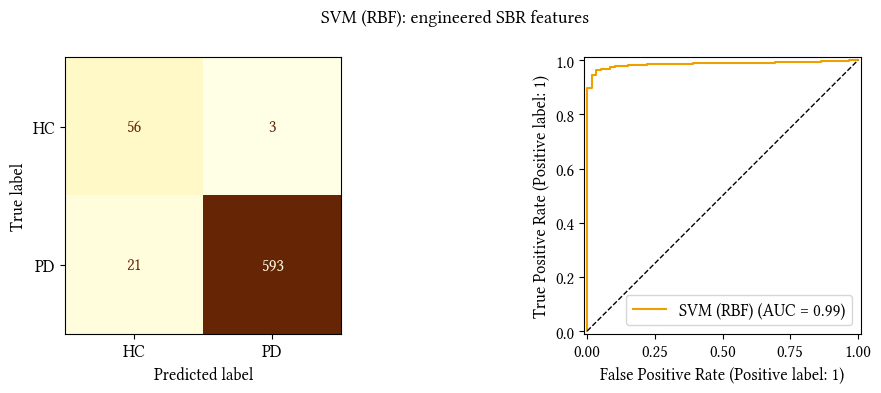

In [16]:
# Final eval: best model, engineered features 

ROC_COLOR  = "#eea000"   # line colour for the ROC curve
CMAP_NAME  = "YlOrBr"     # any matplotlib colormap: "Blues", "Purples", "RdBu", etc.

best_name = "SVM (RBF)"  # update after inspecting CV results

X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y_eng, test_size=0.2, stratify=y_eng, random_state=RANDOM_STATE
)

best_pipe = Pipeline([("scaler", StandardScaler()), ("clf", classifiers[best_name])])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print(f"\n{best_name} — engineered features, hold-out report")
print(classification_report(y_test, y_pred, target_names=["HC", "PD"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["HC", "PD"],
    ax=axes[0],
    colorbar=False,
    cmap=CMAP_NAME
)

RocCurveDisplay.from_predictions(
    y_test, y_prob,
    ax=axes[1],
    color=ROC_COLOR,
    name=best_name
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1)

fig.suptitle(f"{best_name}: engineered SBR features", fontsize=13)
plt.tight_layout()
plt.savefig("best_model_eval.svg", format="svg", bbox_inches="tight")
plt.show()

# About this graph
Dummy way to zoom on the model I want to see better.

In [17]:
# from matplotlib import colormaps

# i = 0
# for cmap in colormaps:
#     print(f'{cmap}, ', end='')
#     i += 1
#     if i > 8:
#         print()
#         i = 0

# Manual balancing of data

As a quick sanity check, I'd like to see the results of the same tests but using a 50/50 split of each class in the original data.
This way I avoid possible biases generated using the `balanced classifier` from scikit.

In [18]:
# Manual balancing: undersample PD to match HC count

n_hc = (y == 0).sum()
pd_idx = np.where(y == 1)[0]
hc_idx = np.where(y == 0)[0]

pd_downsampled = np.random.RandomState(RANDOM_STATE).choice(pd_idx, size=n_hc, replace=False)
balanced_idx = np.concatenate([pd_downsampled, hc_idx])

X_bal     = X[balanced_idx]           # raw features, balanced
X_eng_bal = X_eng[balanced_idx]       # engineered features, balanced
y_bal     = y[balanced_idx]

print(f"Balanced data PD: {(y_bal==1).sum()}, HC: {(y_bal==0).sum()}")

Balanced data PD: 296, HC: 296


In [19]:
# CV on all four dataset variants

datasets = {
    "Raw (weighted)":        (X,         y),
    "Engineered (weighted)": (X_eng,     y),
    "Raw (balanced)":        (X_bal,     y_bal),
    "Engineered (balanced)": (X_eng_bal, y_bal),
}

all_results = {}
for dataset_name, (X_d, y_d) in datasets.items():
    print(f"\n{dataset_name}")
    all_results[dataset_name] = {}
    for name, clf in classifiers.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        scores = cross_validate(pipe, X_d, y_d, cv=cv, scoring=scoring, n_jobs=-1)
        all_results[dataset_name][name] = scores
        print(f"  {name:25s}  AUC: {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}  |  BalAcc: {scores['test_balanced_accuracy'].mean():.3f}  |  F1: {scores['test_f1'].mean():.3f}")


Raw (weighted)
  SVM (RBF)                  AUC: 0.988 ± 0.005  |  BalAcc: 0.974  |  F1: 0.983
  SVM (Linear)               AUC: 0.991 ± 0.003  |  BalAcc: 0.967  |  F1: 0.981
  Random Forest              AUC: 0.988 ± 0.006  |  BalAcc: 0.946  |  F1: 0.989
  Gradient Boosting          AUC: 0.986 ± 0.007  |  BalAcc: 0.939  |  F1: 0.988
  Logistic Regression        AUC: 0.991 ± 0.003  |  BalAcc: 0.966  |  F1: 0.982

Engineered (weighted)
  SVM (RBF)                  AUC: 0.990 ± 0.006  |  BalAcc: 0.975  |  F1: 0.984
  SVM (Linear)               AUC: 0.994 ± 0.002  |  BalAcc: 0.971  |  F1: 0.983
  Random Forest              AUC: 0.990 ± 0.006  |  BalAcc: 0.943  |  F1: 0.989
  Gradient Boosting          AUC: 0.990 ± 0.006  |  BalAcc: 0.939  |  F1: 0.988
  Logistic Regression        AUC: 0.994 ± 0.002  |  BalAcc: 0.971  |  F1: 0.984

Raw (balanced)
  SVM (RBF)                  AUC: 0.990 ± 0.010  |  BalAcc: 0.968  |  F1: 0.968
  SVM (Linear)               AUC: 0.991 ± 0.008  |  BalAcc: 0.959

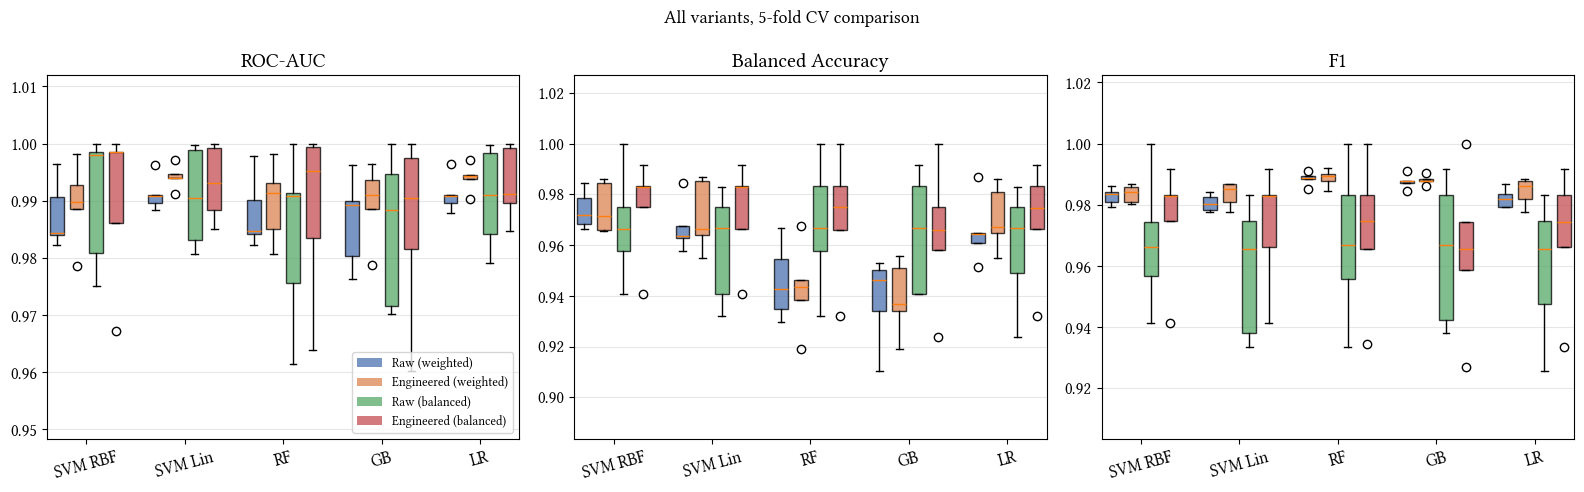

In [20]:
# Comparison plot: one row per metric, one group per dataset

metrics = {"ROC-AUC": "test_roc_auc", "Balanced Accuracy": "test_balanced_accuracy", "F1": "test_f1"}
dataset_names = list(all_results.keys())
short_names   = ["SVM RBF", "SVM Lin", "RF", "GB", "LR"]
dataset_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric_label, key) in zip(axes, metrics.items()):
    all_vals = []
    for i, ds_name in enumerate(dataset_names):
        data = [all_results[ds_name][clf_name][key] for clf_name in classifiers]
        positions = np.arange(len(classifiers)) * (len(dataset_names) + 1) + i
        bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set(facecolor=dataset_colors[i], alpha=0.75)
        all_vals.extend([v for d in data for v in d])

    margin = (max(all_vals) - min(all_vals)) * 0.3
    ax.set_ylim(min(all_vals) - margin, max(all_vals) + margin)

    group_centers = np.arange(len(classifiers)) * (len(dataset_names) + 1) + (len(dataset_names) - 1) / 2
    ax.set_xticks(group_centers)
    ax.set_xticklabels(short_names, rotation=15)
    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)

legend_patches = [plt.matplotlib.patches.Patch(facecolor=c, alpha=0.75, label=n)
                  for c, n in zip(dataset_colors, dataset_names)]
axes[0].legend(handles=legend_patches, fontsize=9, loc="lower right")

fig.suptitle("All variants, 5-fold CV comparison", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_all_variants.svg", format="svg", bbox_inches="tight")
plt.show()

## About this balanced vs balanced graph

In this graph I've compared all the models, and, for each, the performance using raw (the 4 params) vs raw+engineered features, and balancing manually vs balancing automatically.

Conclusions then:
- Engineered outperforms raw on all models and balancing methods
- SVM seems to perform best
- Manually balanced seems worse here bcs I forgot to add precision and recall.


SVM (RBF), engineered features, hold-out report
              precision    recall  f1-score   support

          HC       0.98      0.93      0.96        60
          PD       0.94      0.98      0.96        59

    accuracy                           0.96       119
   macro avg       0.96      0.96      0.96       119
weighted avg       0.96      0.96      0.96       119



/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


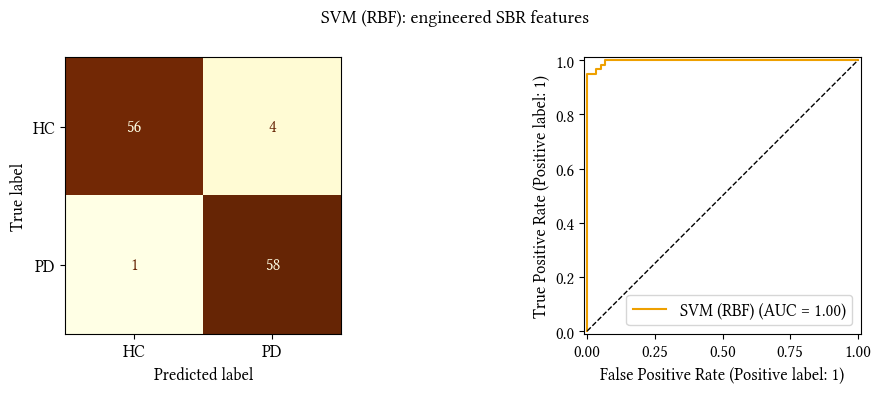

In [21]:
# Final eval: best model, engineered features, manually balanced
best_name = "SVM (RBF)"  # update after inspecting CV results

X_train, X_test, y_train, y_test = train_test_split(
    X_eng_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=RANDOM_STATE
)

best_pipe = Pipeline([("scaler", StandardScaler()), ("clf", classifiers[best_name])])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print(f"\n{best_name}, engineered features, hold-out report")
print(classification_report(y_test, y_pred, target_names=["HC", "PD"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["HC", "PD"],
    ax=axes[0],
    colorbar=False,
    cmap=CMAP_NAME
)

RocCurveDisplay.from_predictions(
    y_test, y_prob,
    ax=axes[1],
    color=ROC_COLOR,
    name=best_name
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1)

fig.suptitle(f"{best_name}: engineered SBR features", fontsize=13)
plt.tight_layout()
#plt.savefig("best_model_eval.svg", format="svg", bbox_inches="tight")
plt.show()

The metrics for the HC class increased a bunch, which could indicate that the previous automatic balancing was not really working all that well.


### Same but rewritten to sound better for my report:

The contrast is stark and informative. With auto-balancing (class weights), the model learns to prioritise recall for PD --- it catches 97% of PD cases but HC precision is only 0.73, meaning many HC patients get flagged as PD. This is the classic imbalanced-data behaviour: the model is hedging toward the majority class prediction to minimise weighted loss. The manually balanced dataset fixes this almost completely --- both classes sit at 0.93--0.98 across all metrics, and the macro averages equalise. The fact that overall accuracy is identical (0.96) in both cases is a perfect illustration of why accuracy alone is meaningless under imbalance: one model is quietly misclassifying a quarter of healthy patients, and accuracy doesn't catch it.

# Final comparison

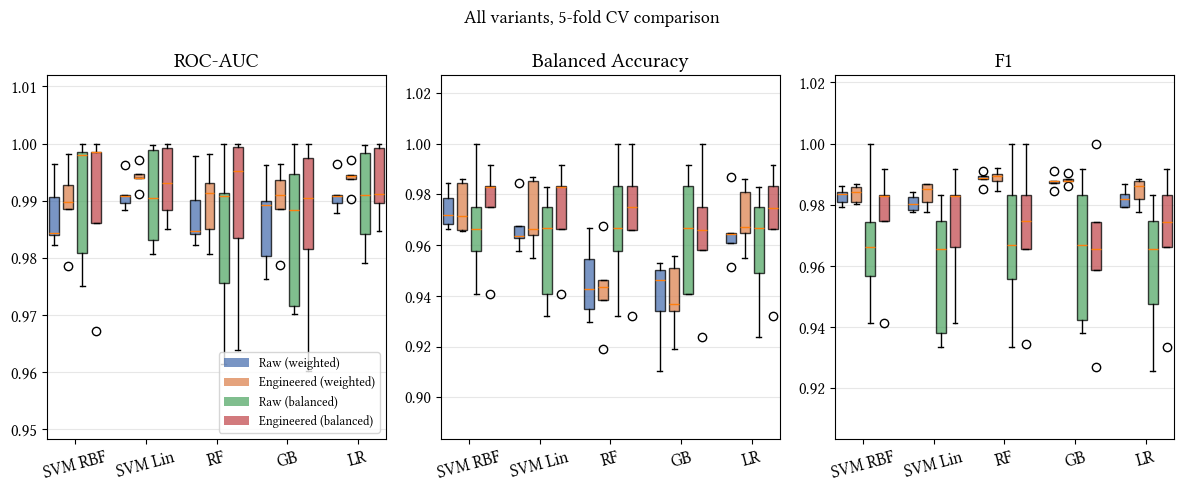

In [22]:
metrics = {
    "ROC-AUC":            "test_roc_auc",
    "Balanced Accuracy":  "test_balanced_accuracy",
    "F1":                 "test_f1",
    #"Precision":          "test_precision",
    #"Recall":             "test_recall",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, (metric_label, key) in zip(axes, metrics.items()):
    all_vals = []
    for i, ds_name in enumerate(dataset_names):
        data = [all_results[ds_name][clf_name][key] for clf_name in classifiers]
        positions = np.arange(len(classifiers)) * (len(dataset_names) + 1) + i
        bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set(facecolor=dataset_colors[i], alpha=0.75)
        all_vals.extend([v for d in data for v in d])

    margin = (max(all_vals) - min(all_vals)) * 0.3
    ax.set_ylim(min(all_vals) - margin, max(all_vals) + margin)
    group_centers = np.arange(len(classifiers)) * (len(dataset_names) + 1) + (len(dataset_names) - 1) / 2
    ax.set_xticks(group_centers)
    ax.set_xticklabels(short_names, rotation=15)
    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)

legend_patches = [plt.matplotlib.patches.Patch(facecolor=c, alpha=0.75, label=n)
                  for c, n in zip(dataset_colors, dataset_names)]
axes[0].legend(handles=legend_patches, fontsize=9, loc="lower right")

fig.suptitle("All variants, 5-fold CV comparison", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_all_variants.svg", format="svg", bbox_inches="tight")
plt.show()

# Heads up

This graph shows recall and precision only for the PD class (how good the model is at catching PD).

The following shows the average of recall and precision for both HC and PD classes, which is a bit more relevant.

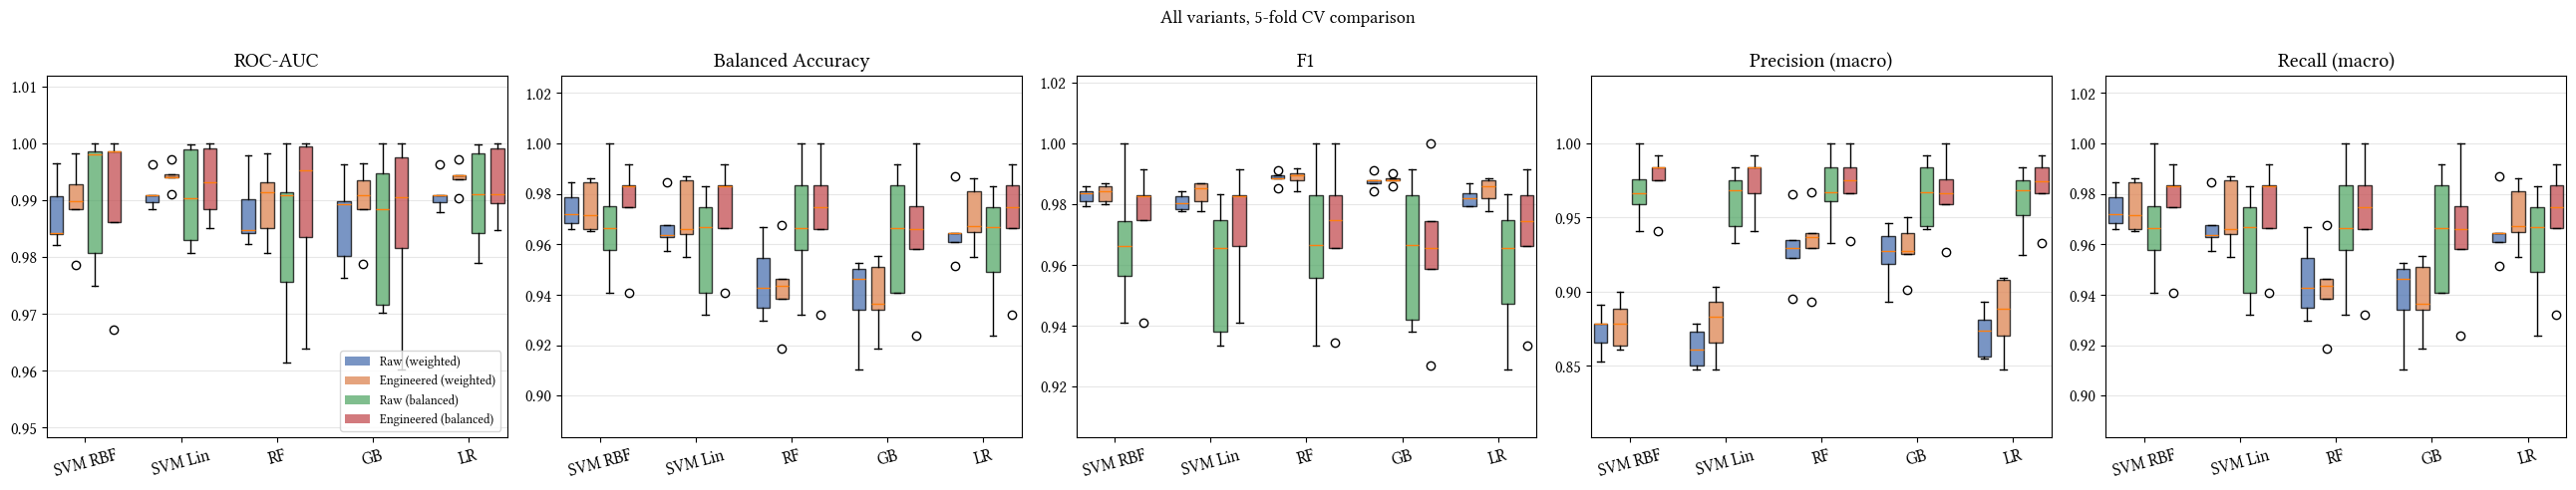

In [23]:
from sklearn.metrics import make_scorer, precision_score, recall_score

scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc",
    "f1":                "f1",
    "precision_macro":   make_scorer(precision_score, average="macro"),
    "recall_macro":      make_scorer(recall_score, average="macro"),
}

datasets = {
    "Raw (weighted)":        (X,         y),
    "Engineered (weighted)": (X_eng,     y),
    "Raw (balanced)":        (X_bal,     y_bal),
    "Engineered (balanced)": (X_eng_bal, y_bal),
}

# Rerun CV with updated scoring
all_results = {}
for ds_name, (X_d, y_d) in datasets.items():
    all_results[ds_name] = {}
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        scores = cross_validate(pipe, X_d, y_d, cv=cv, scoring=scoring, n_jobs=-1)
        all_results[ds_name][clf_name] = scores

# Plot
metrics = {
    "ROC-AUC":           "test_roc_auc",
    "Balanced Accuracy": "test_balanced_accuracy",
    "F1":                "test_f1",
    "Precision (macro)": "test_precision_macro",
    "Recall (macro)":    "test_recall_macro",
}

dataset_names  = list(all_results.keys())
short_names    = ["SVM RBF", "SVM Lin", "RF", "GB", "LR"]
dataset_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 5, figsize=(26, 5))

for ax, (metric_label, key) in zip(axes, metrics.items()):
    all_vals = []
    for i, ds_name in enumerate(dataset_names):
        data = [all_results[ds_name][clf_name][key] for clf_name in classifiers]
        positions = np.arange(len(classifiers)) * (len(dataset_names) + 1) + i
        bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set(facecolor=dataset_colors[i], alpha=0.75)
        all_vals.extend([v for d in data for v in d])

    margin = (max(all_vals) - min(all_vals)) * 0.3
    ax.set_ylim(min(all_vals) - margin, max(all_vals) + margin)
    group_centers = np.arange(len(classifiers)) * (len(dataset_names) + 1) + (len(dataset_names) - 1) / 2
    ax.set_xticks(group_centers)
    ax.set_xticklabels(short_names, rotation=15)
    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)

legend_patches = [plt.matplotlib.patches.Patch(facecolor=c, alpha=0.75, label=n)
                  for c, n in zip(dataset_colors, dataset_names)]
axes[0].legend(handles=legend_patches, fontsize=9, loc="lower right")
fig.suptitle("All variants, 5-fold CV comparison", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_all_variants.svg", format="svg", bbox_inches="tight")
plt.show()

## About this final one

Now this is the final, good one. I plotted precision and recall as well, showing how bad the `weighted` method works vs just manually dropping a bunch of samples.
This still compares the same models, balanced vs unbalanced, raw vs raw-derived features.

Conclusions here:
- SVM is the best
- Manually balancing is the way to go
- Engineered (raw-derived features) work best

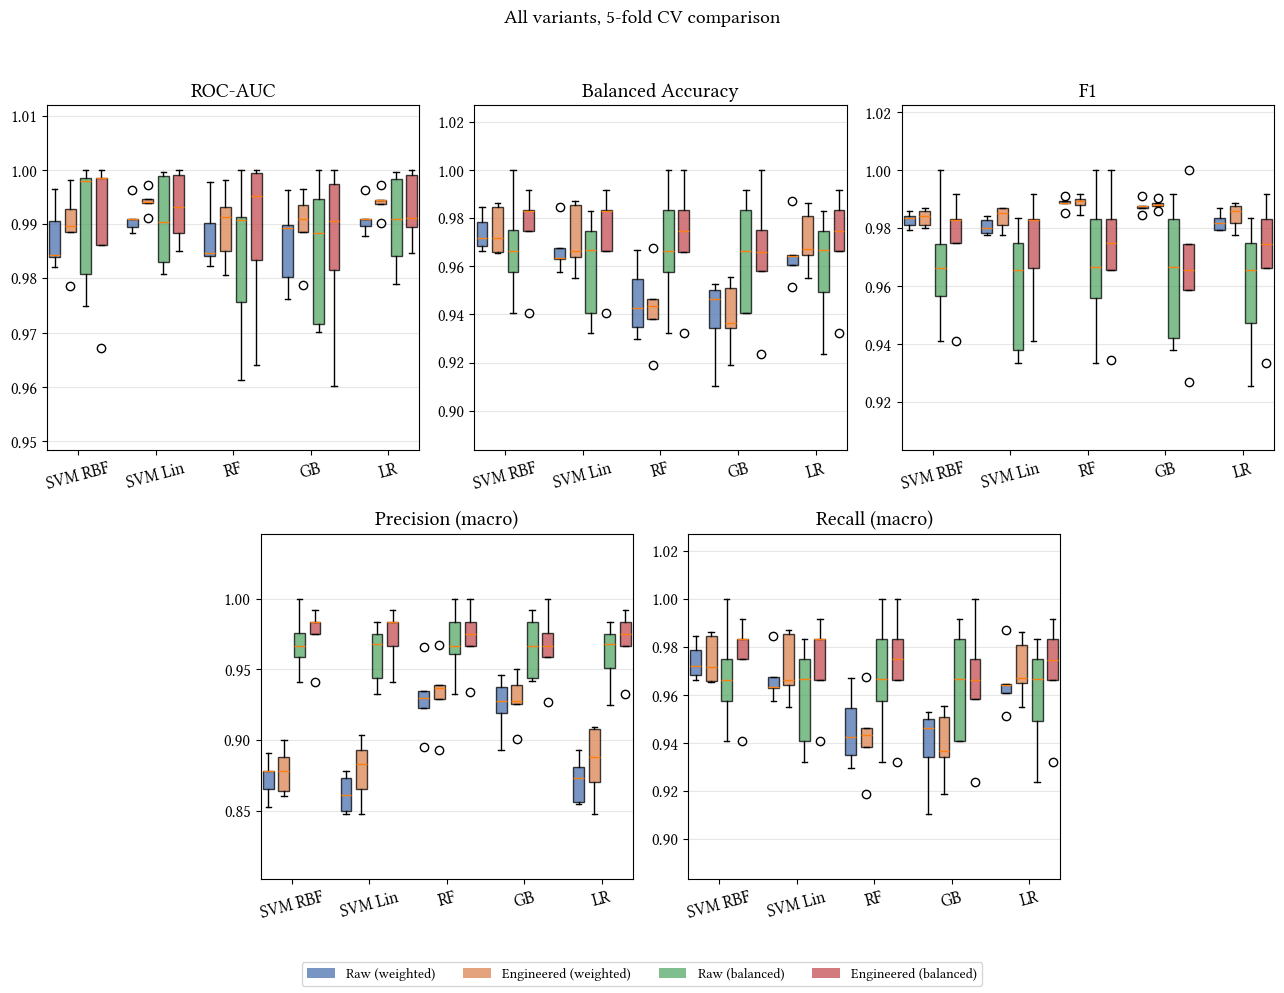

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# (Your previous setup code for scoring, datasets, and cross-validation remains the same)

# Plot
metrics = {
    "ROC-AUC":           "test_roc_auc",
    "Balanced Accuracy": "test_balanced_accuracy",
    "F1":                "test_f1",
    "Precision (macro)": "test_precision_macro",
    "Recall (macro)":    "test_recall_macro",
}

dataset_names  = list(all_results.keys())
short_names    = ["SVM RBF", "SVM Lin", "RF", "GB", "LR"]
dataset_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# 1. Change figure size for a 2-row layout and initialize GridSpec (2 rows, 6 columns)
fig = plt.figure(figsize=(13, 10))
gs = fig.add_gridspec(2, 6)

# 2. Manually define the axes positions to achieve the centered 3x2 effect
axes = [
    fig.add_subplot(gs[0, 0:2]), # Top Row: Left
    fig.add_subplot(gs[0, 2:4]), # Top Row: Middle
    fig.add_subplot(gs[0, 4:6]), # Top Row: Right
    fig.add_subplot(gs[1, 1:3]), # Bottom Row: Left (Centered)
    fig.add_subplot(gs[1, 3:5])  # Bottom Row: Right (Centered)
]

for ax, (metric_label, key) in zip(axes, metrics.items()):
    all_vals = []
    for i, ds_name in enumerate(dataset_names):
        data = [all_results[ds_name][clf_name][key] for clf_name in classifiers]
        positions = np.arange(len(classifiers)) * (len(dataset_names) + 1) + i
        bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set(facecolor=dataset_colors[i], alpha=0.75)
        all_vals.extend([v for d in data for v in d])

    margin = (max(all_vals) - min(all_vals)) * 0.3
    ax.set_ylim(min(all_vals) - margin, max(all_vals) + margin)
    group_centers = np.arange(len(classifiers)) * (len(dataset_names) + 1) + (len(dataset_names) - 1) / 2
    ax.set_xticks(group_centers)
    ax.set_xticklabels(short_names, rotation=15)
    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)

# 3. Create a figure-level legend positioned cleanly at the bottom center
legend_patches = [plt.matplotlib.patches.Patch(facecolor=c, alpha=0.75, label=n)
                  for c, n in zip(dataset_colors, dataset_names)]

fig.legend(handles=legend_patches, loc="lower center", ncol=len(dataset_names), fontsize=10)

fig.suptitle("All variants, 5-fold CV comparison", fontsize=14, y=0.98)

# 4. Use the 'rect' padding option so tight_layout doesn't overlap the legend or title
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig("comparison_all_variants.svg", format="svg", bbox_inches="tight")
plt.show()

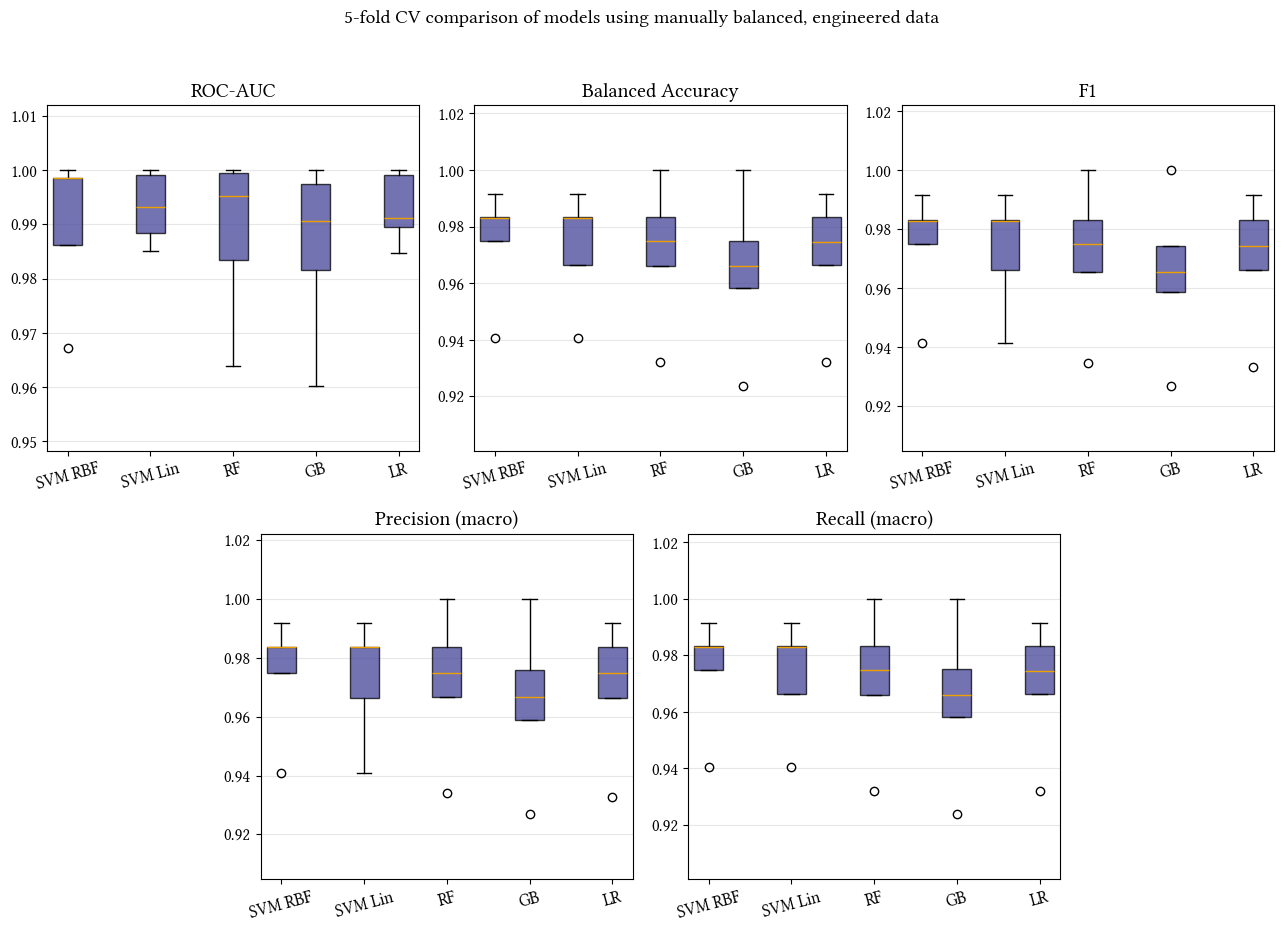

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# now plot leaving only the engineered and manually balanced
datasets = {
    "Engineered (balanced)": (X_eng_bal, y_bal),
}

all_results = {}
for ds_name, (X_d, y_d) in datasets.items():
    all_results[ds_name] = {}
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        scores = cross_validate(pipe, X_d, y_d, cv=cv, scoring=scoring, n_jobs=-1)
        all_results[ds_name][clf_name] = scores

# Plot
metrics = {
    "ROC-AUC":           "test_roc_auc",
    "Balanced Accuracy": "test_balanced_accuracy",
    "F1":                "test_f1",
    "Precision (macro)": "test_precision_macro",
    "Recall (macro)":    "test_recall_macro",
}

dataset_names  = list(all_results.keys())
short_names    = ["SVM RBF", "SVM Lin", "RF", "GB", "LR"]
dataset_colors = ["#444499", "#FFFFFF" ]

fig = plt.figure(figsize=(13, 10))
gs = fig.add_gridspec(2, 6)

# 2. Manually define the axes positions to achieve the centered 3x2 effect
axes = [
    fig.add_subplot(gs[0, 0:2]), # Top Row: Left
    fig.add_subplot(gs[0, 2:4]), # Top Row: Middle
    fig.add_subplot(gs[0, 4:6]), # Top Row: Right
    fig.add_subplot(gs[1, 1:3]), # Bottom Row: Left (Centered)
    fig.add_subplot(gs[1, 3:5])  # Bottom Row: Right (Centered)
]

for ax, (metric_label, key) in zip(axes, metrics.items()):
    all_vals = []
    for i, ds_name in enumerate(dataset_names):
        data = [all_results[ds_name][clf_name][key] for clf_name in classifiers]
        positions = np.arange(len(classifiers)) * (len(dataset_names) + 1) + i
        bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True, medianprops={"color": "#eea000"})
        for patch in bp["boxes"]:
            patch.set(facecolor=dataset_colors[i], alpha=0.75)
        all_vals.extend([v for d in data for v in d])

    margin = (max(all_vals) - min(all_vals)) * 0.3
    ax.set_ylim(min(all_vals) - margin, max(all_vals) + margin)
    group_centers = np.arange(len(classifiers)) * (len(dataset_names) + 1) + (len(dataset_names) - 1) / 2
    ax.set_xticks(group_centers)
    ax.set_xticklabels(short_names, rotation=15)
    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)


fig.suptitle("5-fold CV comparison of models using manually balanced, engineered data", fontsize=14, y=0.98)

# 4. Use the 'rect' padding option so tight_layout doesn't overlap the legend or title
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig("comparison_models_only.svg", format="svg", bbox_inches="tight")
plt.show()